# Pseudo-Label Quality Check

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

PROJECT_ROOT

WindowsPath('D:/Projects/Personal Projects/Hairstyle Recommender Live Tryon')

In [2]:
import json
from pathlib import Path

import pandas as pd
from PIL import Image

from app.ml.celeba_hair_rich import enrich_quality_records, quality_summary, read_jsonl, write_jsonl

DATASET_ROOT = BACKEND_ROOT / 'data' / 'datasets' / 'celeba_hair_rich'
TRAIN_PATH = DATASET_ROOT / 'train.jsonl'
VAL_PATH = DATASET_ROOT / 'val.jsonl'
TEST_PATH = DATASET_ROOT / 'test.jsonl'
QUALITY_SUMMARY_PATH = DATASET_ROOT / 'quality_summary.json'
FILTERED_TRAIN_PATH = DATASET_ROOT / 'train_quality_filtered.jsonl'
FILTERED_VAL_PATH = DATASET_ROOT / 'val_quality_filtered.jsonl'
FILTERED_TEST_PATH = DATASET_ROOT / 'test_quality_filtered.jsonl'

print(DATASET_ROOT)

D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\datasets\celeba_hair_rich


In [3]:
train_records = enrich_quality_records(read_jsonl(TRAIN_PATH))
val_records = enrich_quality_records(read_jsonl(VAL_PATH))
test_records = enrich_quality_records(read_jsonl(TEST_PATH))

print('train', len(train_records))
print('val', len(val_records))
print('test', len(test_records))

train 4000
val 1000
test 1000


In [4]:
summary = {
    'train': quality_summary(train_records),
    'val': quality_summary(val_records),
    'test': quality_summary(test_records),
}

QUALITY_SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary

{'train': {'total_records': 4000,
  'usable_candidates': 3100,
  'usable_ratio': 0.775,
  'avg_quality_score': 0.858,
  'flag_counts': {'usable_candidate': 3100,
   'touches_left_edge': 1243,
   'short_mask': 765,
   'touches_top_edge': 470,
   'narrow_mask': 399,
   'low_coverage': 246,
   'high_coverage': 23}},
 'val': {'total_records': 1000,
  'usable_candidates': 760,
  'usable_ratio': 0.76,
  'avg_quality_score': 0.8422,
  'flag_counts': {'usable_candidate': 760,
   'touches_left_edge': 328,
   'short_mask': 206,
   'touches_top_edge': 115,
   'narrow_mask': 108,
   'low_coverage': 81,
   'high_coverage': 10}},
 'test': {'total_records': 1000,
  'usable_candidates': 794,
  'usable_ratio': 0.794,
  'avg_quality_score': 0.8634,
  'flag_counts': {'usable_candidate': 794,
   'touches_left_edge': 343,
   'short_mask': 181,
   'touches_top_edge': 108,
   'narrow_mask': 80,
   'low_coverage': 60,
   'high_coverage': 4}}}

In [5]:
def records_to_frame(records):
    rows = []
    for record in records:
        stats = record['hair_mask_stats']
        rows.append({
            'image_id': record['image_id'],
            'partition': record['partition'],
            'gender_label': record['gender_label'],
            'quality_score': record['quality_score'],
            'usable_candidate': record['usable_candidate'],
            'coverage_ratio': stats['coverage_ratio'],
            'bbox_width': stats['bbox_width'],
            'bbox_height': stats['bbox_height'],
            'bbox_x': stats['bbox_x'],
            'bbox_y': stats['bbox_y'],
            'quality_flags': ', '.join(record['quality_flags']),
        })
    return pd.DataFrame(rows)

train_frame = records_to_frame(train_records)
val_frame = records_to_frame(val_records)
test_frame = records_to_frame(test_records)

display(train_frame.head())
display(train_frame['usable_candidate'].value_counts().rename('count').to_frame())

,image_id,partition,gender_label,quality_score,usable_candidate,coverage_ratio,bbox_width,bbox_height,bbox_x,bbox_y,quality_flags
0,000001.jpg,train,female,0.76,True,0.521338,178,218,0,0,"touches_left_edge, touches_top_edge, usable_ca..."
1,000002.jpg,train,female,1.00,True,0.279817,144,214,34,3,usable_candidate
2,000003.jpg,train,male,0.40,False,0.080481,96,101,22,22,"narrow_mask, short_mask"
3,000004.jpg,train,female,0.58,False,0.634265,178,218,0,0,"high_coverage, touches_left_edge, touches_top_..."
4,000006.jpg,train,female,1.00,True,0.403489,171,201,7,17,usable_candidate


,count
usable_candidate,
True,3100
False,900


In [6]:
display(train_frame[['quality_score', 'coverage_ratio', 'bbox_width', 'bbox_height']].describe())
display(train_frame.sort_values('quality_score', ascending=False).head(10))
display(train_frame.sort_values('quality_score', ascending=True).head(10))

,quality_score,coverage_ratio,bbox_width,bbox_height
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.858000,0.271275,139.903500,159.348250
std,0.217371,0.139851,29.252805,45.434998
min,0.070000,0.000052,2.000000,1.000000
25%,0.800000,0.147331,118.000000,114.000000
50%,0.920000,0.262989,142.000000,178.000000
75%,1.000000,0.382022,165.000000,196.000000
max,1.000000,0.768323,178.000000,218.000000


,image_id,partition,gender_label,quality_score,usable_candidate,coverage_ratio,bbox_width,bbox_height,bbox_x,bbox_y,quality_flags
3982,004948.jpg,train,male,1.0,True,0.157484,121,120,38,14,usable_candidate
3980,004944.jpg,train,female,1.0,True,0.253943,152,176,5,42,usable_candidate
3977,004938.jpg,train,female,1.0,True,0.323523,155,198,6,20,usable_candidate
3975,004936.jpg,train,female,1.0,True,0.295227,143,181,31,37,usable_candidate
3972,004932.jpg,train,female,1.0,True,0.206602,128,192,10,26,usable_candidate
3970,004929.jpg,train,female,1.0,True,0.192841,121,175,42,43,usable_candidate
3969,004928.jpg,train,female,1.0,True,0.126353,111,151,67,41,usable_candidate
31,000033.jpg,train,male,1.0,True,0.215802,173,204,1,13,usable_candidate
30,000032.jpg,train,male,1.0,True,0.138903,119,189,22,28,usable_candidate
27,000029.jpg,train,female,1.0,True,0.313499,170,217,1,1,usable_candidate


,image_id,partition,gender_label,quality_score,usable_candidate,coverage_ratio,bbox_width,bbox_height,bbox_x,bbox_y,quality_flags
1790,002225.jpg,train,male,0.07,False,0.077080,90,71,0,41,"low_coverage, narrow_mask, short_mask, touches..."
2952,003663.jpg,train,male,0.07,False,0.072106,92,103,0,71,"low_coverage, narrow_mask, short_mask, touches..."
1285,001598.jpg,train,male,0.07,False,0.039790,41,58,0,66,"low_coverage, narrow_mask, short_mask, touches..."
3965,004923.jpg,train,female,0.15,False,0.024379,87,69,45,49,"low_coverage, narrow_mask, short_mask"
3963,004920.jpg,train,male,0.15,False,0.050459,58,76,3,53,"low_coverage, narrow_mask, short_mask"
3121,003875.jpg,train,male,0.15,False,0.045382,103,68,28,50,"low_coverage, narrow_mask, short_mask"
1224,001529.jpg,train,male,0.15,False,0.070560,90,98,36,9,"low_coverage, narrow_mask, short_mask"
2421,003006.jpg,train,male,0.15,False,0.077389,99,92,30,40,"low_coverage, narrow_mask, short_mask"
3206,003970.jpg,train,male,0.15,False,0.055200,101,78,43,43,"low_coverage, narrow_mask, short_mask"
2005,002504.jpg,train,male,0.15,False,0.012653,17,48,122,75,"low_coverage, narrow_mask, short_mask"


In [7]:
filtered_train = [record for record in train_records if record['usable_candidate']]
filtered_val = [record for record in val_records if record['usable_candidate']]
filtered_test = [record for record in test_records if record['usable_candidate']]

write_jsonl(filtered_train, FILTERED_TRAIN_PATH)
write_jsonl(filtered_val, FILTERED_VAL_PATH)
write_jsonl(filtered_test, FILTERED_TEST_PATH)

{
    'filtered_train': len(filtered_train),
    'filtered_val': len(filtered_val),
    'filtered_test': len(filtered_test),
}

{'filtered_train': 3100, 'filtered_val': 760, 'filtered_test': 794}

good 000001.jpg 0.76 ['touches_left_edge', 'touches_top_edge', 'usable_candidate']


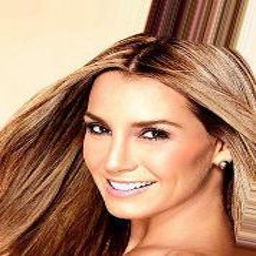

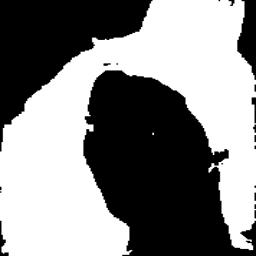

bad 000003.jpg 0.4 ['narrow_mask', 'short_mask']


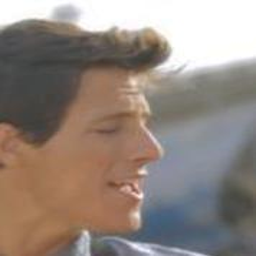

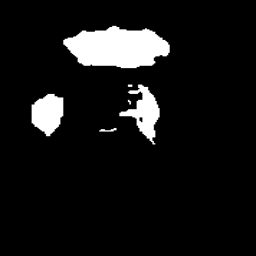

In [8]:
sample_good = filtered_train[0] if filtered_train else None
sample_bad = next((record for record in train_records if not record['usable_candidate']), None)

for label, record in [('good', sample_good), ('bad', sample_bad)]:
    if record is None:
        print(label, 'sample not available')
        continue
    print(label, record['image_id'], record['quality_score'], record['quality_flags'])
    display(Image.open(record['image_path']).convert('RGB').resize((256, 256)))
    display(Image.open(record['segmentation_mask_path']).convert('L').resize((256, 256)))